[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sibbirhossain/finguard-xai/blob/main/notebooks/06_impact_scenario_analysis.ipynb)

# 06 · Operational Impact — Scenario Analysis

> **SCENARIO ANALYSIS.** This notebook combines *measured* detection rates from this project with *stated, editable assumptions* about a hypothetical institution. The outputs are illustrations of how the measured differences would translate operationally. They are not observed savings.

**Method.**
- Precision depends on the fraud base rate, so it does not transfer between datasets. This analysis therefore uses the **base-rate-independent** quantities measured in the 5-seed experiments: recall (the share of fraud caught) and false-positive rate (the share of legitimate traffic flagged).
- Daily alerts = N × (fraud_rate × recall + (1 − fraud_rate) × FPR).
- Fraud dollars intercepted = N × fraud_rate × recall × average fraud loss.

In [1]:
# --- Setup: works in Google Colab and inside a local clone ---
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")
if os.path.exists("../src/models"):
    os.chdir("..")
elif not os.path.exists("src/models"):
    if not os.path.exists("finguard-xai"):
        subprocess.run(["git", "clone", "-q", "https://github.com/sibbirhossain/finguard-xai.git"], check=True)
    os.chdir("finguard-xai")
try:
    import torch_geometric  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"], check=True)
sys.path.insert(0, os.getcwd())
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("ready:", os.getcwd())

ready: /home/claude/finguard-xai


In [2]:
# ---- Editable assumptions (hypothetical institution) ----
DAILY_TRANSACTIONS = 1_000_000      # card/payment events per day
FRAUD_RATE         = 0.001          # 0.1% of transactions fraudulent (assumption)
AVG_FRAUD_LOSS     = 350.0          # US$ lost per undetected fraudulent transaction (assumption)
REVIEW_COST        = 4.0            # US$ analyst cost to review one alert (assumption)

exp = json.loads(open("reports/EXPERIMENTS.json").read())["standard"]
models = {"GBDT (no graph)": "tabular_gbdt_no_graph", "Temporal GNN": "gnn_only", "GNN + dual-channel": "hybrid_gnn_plus_anomaly"}
import pandas as pd
rows = {}
for name, k in models.items():
    rec, fpr = exp[k]["recall"][0], exp[k]["fpr"][0]
    alerts = DAILY_TRANSACTIONS * (FRAUD_RATE * rec + (1 - FRAUD_RATE) * fpr)
    caught = DAILY_TRANSACTIONS * FRAUD_RATE * rec * AVG_FRAUD_LOSS
    rows[name] = {"measured recall": rec, "measured FPR": fpr, "alerts/day": alerts,
                  "fraud $ intercepted/day": caught, "review cost/day": alerts * REVIEW_COST,
                  "net $/day": caught - alerts * REVIEW_COST}
df = pd.DataFrame(rows).T
df.style.format({"measured recall": "{:.3f}", "measured FPR": "{:.4f}", "alerts/day": "{:,.0f}", "fraud $ intercepted/day": "${:,.0f}",
                 "review cost/day": "${:,.0f}", "net $/day": "${:,.0f}"})

,measured recall,measured FPR,alerts/day,fraud $ intercepted/day,review cost/day,net $/day
GBDT (no graph),0.719,0.0250,"25,704","$251,774","$102,817","$148,957"
Temporal GNN,0.895,0.0060,"6,860","$313,318","$27,442","$285,877"
GNN + dual-channel,0.912,0.0114,"12,317","$319,043","$49,269","$269,774"


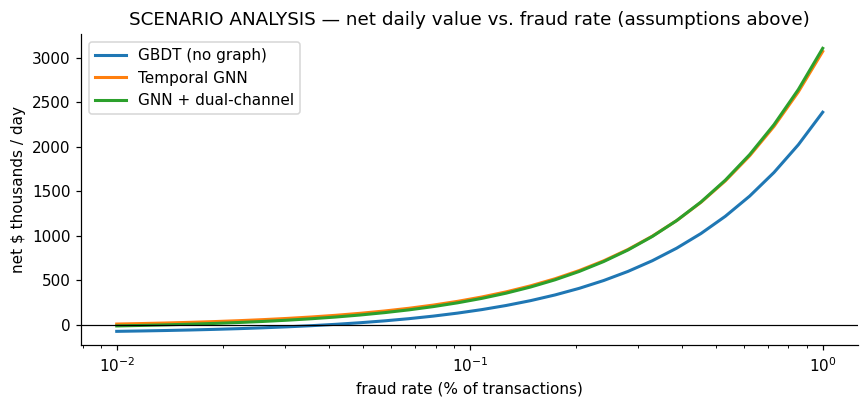

In [3]:
# Sensitivity: how does the graph model's advantage depend on the fraud base rate?
rates = np.logspace(-4, -2, 30)
def net(k, fr):
    rec, fpr = exp[k]["recall"][0], exp[k]["fpr"][0]
    alerts = DAILY_TRANSACTIONS * (fr * rec + (1 - fr) * fpr)
    return DAILY_TRANSACTIONS * fr * rec * AVG_FRAUD_LOSS - alerts * REVIEW_COST
fig, ax = plt.subplots(figsize=(8, 3.8))
for name, k in models.items():
    ax.plot(rates * 100, [net(k, r) / 1e3 for r in rates], label=name, lw=2)
ax.set_xscale("log"); ax.set_xlabel("fraud rate (% of transactions)"); ax.set_ylabel("net $ thousands / day")
ax.axhline(0, color="black", lw=.8); ax.legend()
ax.set_title("SCENARIO ANALYSIS — net daily value vs. fraud rate (assumptions above)"); plt.tight_layout(); plt.show()

### How to read this
- The ranking comes from **measured** recall and false-positive rates.
- The dollar amounts come from the **assumptions** at the top. Change them to match any institution's volumes and costs.
- Real-world impact can only be established by evaluating the model on an institution's own data. That is a stated limitation of this project, not a result.